# About

This jupyter notebook is (one of) the first steps in the pipeline for the human_microbiome_compendium analysis.

Below contains the pipeline for loading the raw data, doing the appropriate filtering, and outputting the dataset files necessary for training & invoking the downstream models.

The dataset name is `v3v4_split_multiproj`.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from typing import *
from common.preprocess import *

In [3]:
""" dataset directory. """
DATASET_NAME = "american_gut"
NOTEBOOK_CACHE = Path("/data/bwh-comppath-seq/youn/human_microbiome_compendium") / DATASET_NAME
NOTEBOOK_CACHE.mkdir(exist_ok=True, parents=True)

# Dataset Files

File locations and metadata.

In [4]:
data_base_dir = Path("/data/cctm/youn/human_microbiome_compendium")

project_metadata_file = data_base_dir / "projects.csv"
asv_sequence_file = data_base_dir / "obs_md.txt.zst"  # tsv format: ASV_NAME    ASV_SEQ, has a header.
abundance_table_dir = data_base_dir / "asv"
sample_metadata_file = data_base_dir / "sample_metadata.tsv"

assert asv_sequence_file.exists(), f"Expected {asv_sequence_file} to exist."
assert asv_sequence_file.is_file(), f"Expected {asv_sequence_file} to be a file."
assert abundance_table_dir.exists(), f"Expected {asv_sequence_file} to exist."
assert abundance_table_dir.is_dir(), f"Expected {abundance_table_dir} to be a directory."
assert sample_metadata_file.exists(), f"Expected {sample_metadata_file} to exist."
assert sample_metadata_file.is_file(), f"Expected {sample_metadata_file} to be a file."

""" Load the project metadata as a pandas dataframe. """
project_metadata = pd.read_csv(project_metadata_file, sep=',')
print("# projects:", project_metadata.shape[0])

""" Load the sample metadata as a pandas dataframe. """
sample_metadata = pd.read_csv(sample_metadata_file, sep='\t')
print("# samples:", sample_metadata.shape[0])

# projects: 482
# samples: 168464


# Projects -- Target Subset by ID

The below project IDs were pre-screened to contain v3-v4 region amplicons, with length at least 400.

In [5]:
PROJECT_IDS = ['PRJEB11419']


for project_id in PROJECT_IDS:
    print_project_info(project_id, sample_metadata)

Project: PRJEB11419
	regions: <ArrowStringArray>
[                         'unknown',      'Europe and Northern America',
 'Northern Africa and Western Asia',            'Australia/New Zealand',
   'Eastern and South-Eastern Asia',               'Sub-Saharan Africa',
  'Latin America and the Caribbean',        'Central and Southern Asia',
                          'Oceania']
Length: 9, dtype: str
	isos: <ArrowStringArray>
['unknown',      'GB',      'US',      'FR',      'IS',      'AT',      'SE',
      'CA',      'CH',      'AM',      'NZ',      'GR',      'NO',      'MY',
      'NL',      'HU',      'KE',      'CO',      'IL',      'BD',      'ES',
      'DK',      'BE',      'IE',      'DE',      'AU',      'ZW',      'FI',
      'IT',      'IN',      'UM',      'AE',      'UG',      'PT',      'HR',
      'LT',      'TR',      'PL',      'BR',      'SG',      'PE']
Length: 41, dtype: str
	num samples: 4850


# Sample & project filtering.

In [6]:
project_subset = project_metadata.loc[
    project_metadata['project'].isin(PROJECT_IDS), 
    :
]

sample_subset = sample_metadata.loc[
    (
        sample_metadata['project'].isin(PROJECT_IDS)
    )
]
print("[*] Stage 1 filter: {} samples remaining".format(sample_subset.shape[0]))

[*] Stage 1 filter: 4850 samples remaining


In [7]:
project_subset, sample_subset, asv_seqs_subset, sample_max_num_asvs = filter_samples_and_asvs(
    project_subset, sample_subset,
    abundance_table_dir=abundance_table_dir,
    asv_sequence_file=asv_sequence_file,
)

[Project PRJEB11419] Read count statistics:
         read_counts
count    4850.000000
mean    68171.349072
std    152080.475485
min         1.000000
25%     17341.750000
50%     22169.500000
75%     33531.500000
max    993123.000000
[Project PRJEB11419] Using read count threshold of 7738.8 < x < 534978.0000000001
*********************************
[*] Stage 2 filter: 4364 samples remaining
                    count
project    iso           
PRJEB11419 unknown   1529
           US        1363
           GB        1136
           CA         125
           AU          41
           IE          25
           NO          15
           NZ          12
           NL          12
           SE          11
           CH          10
           DE          10
           FR           9
           BE           9
           HU           7
           ES           7
           AT           5
           UM           4
           PT           4
           GR           3
           BD           3
          

In [9]:
print("# samples:", sample_subset.shape[0])

# samples: 3851


# Process 16S sequences.

Keep only sequences that are actually 16S. (some are 18s by accident!)

## Run pipeline.

In [10]:
ASV_SEQ_PROCESSING_DIR = NOTEBOOK_CACHE / "asv_16s_processing"
ASV_SEQ_PROCESSING_DIR.mkdir(exist_ok=True, parents=True)

In [11]:
"""
Note: defer_to_hpc option makes this pipeline print HPC instructions and raise an error.
Follow the directions, and re-run this cell.
"""
asv_seqs_subset = pipeline_16s_validation(
    asv_seqs_subset,
    cache_dir=ASV_SEQ_PROCESSING_DIR,
    silva_db=data_base_dir / "silva_nr99_v138.2_train_set.fa.gz",
    vsearch_path='vsearch',
    vsearch_num_threads=12,
    min_identity=0.95,
)

Wrote 13900 sequences to /data/bwh-comppath-seq/youn/human_microbiome_compendium/american_gut/asv_16s_processing/asv_sequences.pre_validation.fasta
VSEARCH found: vsearch v2.30.4_linux_x86_64, 62.5GB RAM, 32 cores
Found 13900 sequences in input file.
Using database: /data/cctm/youn/human_microbiome_compendium/silva_nr99_v138.2_train_set.fa.gz
Minimum identity threshold: 95.0%
Strategy: Keeping only bacterial sequences, filtering out Archaea and Eukaryota

Running VSEARCH on /data/bwh-comppath-seq/youn/human_microbiome_compendium/american_gut/asv_16s_processing/asv_sequences.pre_validation.fasta against /data/cctm/youn/human_microbiome_compendium/silva_nr99_v138.2_train_set.fa.gz...
VSEARCH output /data/bwh-comppath-seq/youn/human_microbiome_compendium/american_gut/asv_16s_processing/vsearch_results.tsv already exists!
Parsing VSEARCH results and filtering for bacterial sequences...

RESULTS SUMMARY
Total sequences analyzed: 13900
Confirmed bacterial sequences: 12808
Rejected - Archaea:

In [12]:
""" Run the alignment. """
asv_sequence_file_pre_alignment = ASV_SEQ_PROCESSING_DIR / "asv_sequences.pre_mothur.fasta"
asv_align_file = ASV_SEQ_PROCESSING_DIR / "asv_alignment.fasta"
REFERENCE_16S_GREENGENES = Path("/data/cctm/youn/human_microbiome_compendium/GREENGENES_16S_DB") / "gg_13_8_99.refalign"

dict_to_fasta(asv_seqs_subset, asv_sequence_file_pre_alignment)
bad_asv_ids = run_mothur(
    in_fasta=asv_sequence_file_pre_alignment,
    out_fasta=asv_align_file,
    reference_16s_path=REFERENCE_16S_GREENGENES,
    n_processors=20,
    remove_frac_below=1.0,
    mothur_cmd="mothur"
)

""" Handle the ASVs that mothur suggests removing. """
print("Removing an additional {} ASVs based on MOTHUR output.".format(len(bad_asv_ids)))
for bad_asv_id in bad_asv_ids:
    del asv_seqs_subset[bad_asv_id]

asv_sequence_file_post_filter = ASV_SEQ_PROCESSING_DIR / "asv_sequences.post_filter.fasta"
dict_to_fasta(asv_seqs_subset, asv_sequence_file_post_filter)

Wrote 12808 sequences to /data/bwh-comppath-seq/youn/human_microbiome_compendium/american_gut/asv_16s_processing/asv_sequences.pre_mothur.fasta
alignment output already exists: /data/bwh-comppath-seq/youn/human_microbiome_compendium/american_gut/asv_16s_processing/asv_alignment.fasta
Removing an additional 43 ASVs based on MOTHUR output.
Wrote 12765 sequences to /data/bwh-comppath-seq/youn/human_microbiome_compendium/american_gut/asv_16s_processing/asv_sequences.post_filter.fasta


## Additional reporting.

### Compute the modal alignment region to reference 16S.

In [13]:
TMP_ECOLI_ALN_DIR = ASV_SEQ_PROCESSING_DIR / "ecoli_aln"
TMP_ECOLI_ALN_DIR.mkdir(exist_ok=True)
REFERENCE_16S_ECOLI = (Path(".") / "ecoli_16s.fasta").resolve()

asv_sequence_file_pre_alignment = TMP_ECOLI_ALN_DIR / "asv_sequences.input.fasta"
asv_align_file_ECOLI = TMP_ECOLI_ALN_DIR / "ecoli_ref_alignments.fasta"
dict_to_fasta(asv_seqs_subset, asv_sequence_file_pre_alignment)
bad_asv_ids = run_mothur(
    in_fasta=asv_sequence_file_pre_alignment,
    out_fasta=asv_align_file_ECOLI,
    reference_16s_path=REFERENCE_16S_ECOLI,
    n_processors=20,
    remove_frac_below=0.0,
    mothur_cmd="mothur"
)

Wrote 12765 sequences to /data/bwh-comppath-seq/youn/human_microbiome_compendium/american_gut/asv_16s_processing/ecoli_aln/asv_sequences.input.fasta
alignment output already exists: /data/bwh-comppath-seq/youn/human_microbiome_compendium/american_gut/asv_16s_processing/ecoli_aln/ecoli_ref_alignments.fasta


In [14]:
from common.preprocess import get_asvs_in_project

refalign_df = pd.read_csv(TMP_ECOLI_ALN_DIR / "asv_sequences.input.align_report", sep='\t')
aln_results = []

for proj_id, proj_section in sample_subset.groupby("project"):
    sample_ids_in_proj = set(proj_section['srs'])
    asv_proj_subset = get_asvs_in_project(proj_id, abundance_table_dir, sample_ids_in_proj, set(asv_seqs_subset.keys()))

    aln_df_section = refalign_df.loc[refalign_df['QueryName'].isin(asv_proj_subset)]
    median_start = int(aln_df_section['TemplateStart'].median())
    median_end = int(aln_df_section['TemplateEnd'].median())
    aln_results.append({"project": proj_id, "n_samples": len(sample_ids_in_proj), "start": median_start, "end": median_end, "length": median_end - median_start + 1})

aln_results = pd.DataFrame(aln_results)

In [15]:
aln_results.sort_values(['start', 'length']).merge(
    project_metadata,
    on='project', suffixes=['_amplicon', '_right'],
    how='left'
).sort_values("n_samples")

,project,n_samples,start,end,length,link,amplicon,avg_length,bead_beating,kit,sample_type,condition,subjects,notes
0,PRJEB11419,3851,557,683,127,https://doi.org/10.1128/mSystems.00031-18,v4,126.93,False,NaN,stool,healthy,adults,NaN


### Histogram of amplicon length.

Max ASV sequence length: 127


Text(0, 0.5, 'Count')

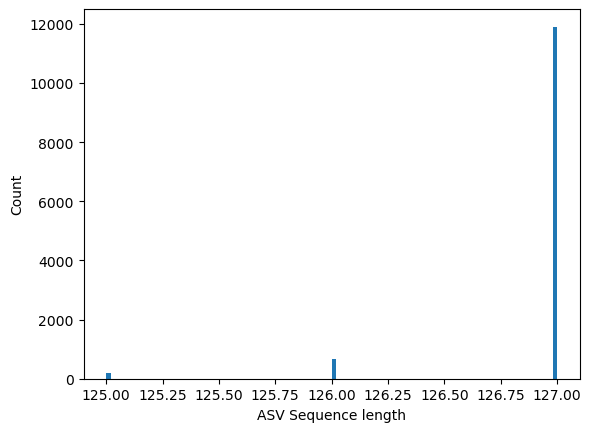

In [16]:
""" Compute the max sequence length. """
MAX_ASV_SEQUENCE_LEN = max(len(s) for s in asv_seqs_subset.values())
print("Max ASV sequence length:", MAX_ASV_SEQUENCE_LEN)

""" Plot ASV length frequency histogram """
fig, ax = plt.subplots(1, 1)
ax.hist([len(s) for s in asv_seqs_subset.values()], bins=100)
ax.set_xlabel("ASV Sequence length")
ax.set_ylabel("Count")

# Train-test split.

In [17]:
# from common.util.distance_matrix import ASVDistanceMatrixPrecomputed

# distmat_file = asv_align_file.parent / "distance_matrix.npz"
# distmat_file.parent.mkdir(exist_ok=True)
# if distmat_file.exists():
#     print(f"file exists! {distmat_file}")
#     dist_mat = ASVDistanceMatrixPrecomputed.load(distmat_file)
# else:
#     dist_mat = ASVDistanceMatrixPrecomputed.from_alignment(asv_align_file)
#     dist_mat.save(asv_align_file.parent / "distance_matrix.npz")

In [18]:
from common.preprocess import compute_sample_distance_matrix
import numpy as np
SAMPLE_DISTMAT_FILE = NOTEBOOK_CACHE / "sample_distmat.jensen_shannon.npz"

if SAMPLE_DISTMAT_FILE.exists():
    print(f"File exists! Loading sample-to-sample distance matrix from: {SAMPLE_DISTMAT_FILE.name}")
    _dmat = np.load(SAMPLE_DISTMAT_FILE)
    sample_dist_mat, sample_dist_mat_order = _dmat['matrix'], _dmat['keys']
else:
    sample_dist_mat, sample_dist_mat_order = compute_sample_distance_matrix(
        sample_df=sample_subset, 
        abundance_table_dir=abundance_table_dir,
        asv_id_subset=set(asv_seqs_subset.keys()), 
        distance_method='jensen_shannon',
        # distance_matrix=dist_mat,
    )
    print(f"Saving sample-to-sample distance matrix to: {SAMPLE_DISTMAT_FILE.name}")
    np.savez(SAMPLE_DISTMAT_FILE, matrix=sample_dist_mat, keys=sample_dist_mat_order)

File exists! Loading sample-to-sample distance matrix from: sample_distmat.jensen_shannon.npz


Using PCOA-based splitting.
Using tail cutoff quantiles q_left = 0.8, q_right = 0.8
Partition is 3080 vs. 771


' ============= Random split. ============= '

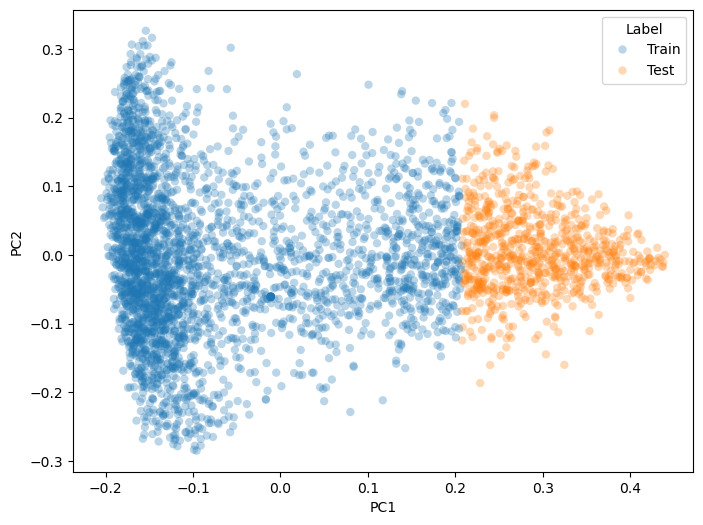

In [24]:
ANALYSIS_DIR = NOTEBOOK_CACHE / "analyses"
ANALYSIS_DIR.mkdir(exist_ok=True)
train_fraction = 0.8
test_fraction = 0.2


analysis_names = []
""" ============== Min-cut approximation split. ============== """
analysis_name = "pcoa_split"
analysis_dir = ANALYSIS_DIR / analysis_name
analysis_dir.mkdir(exist_ok=True)


train_df, test_df, pcoa_df, prop_var = train_test_split(sample_subset, train_fraction, test_fraction, method='pcoa',
                                              sample_dist_mat_order=sample_dist_mat_order, sample_distance_matrix=sample_dist_mat)
train_df.to_csv(analysis_dir / "train.tsv", sep="\t", index=False)
test_df.to_csv(analysis_dir / "test.tsv", sep="\t", index=False)
analysis_names.append(analysis_name)


""" ============= Random split. ============= """
# n_rng_seeds = 10
# rng_seed_start = 100
# for rng_seed in range(rng_seed_start, rng_seed_start + n_rng_seeds):
#     analysis_name = f"random_split_seed_{rng_seed}"
#     analysis_dir = ANALYSIS_DIR / analysis_name
#     analysis_dir.mkdir(exist_ok=True)
#     train_df, test_df, _ = train_test_split(sample_subset, train_fraction, test_fraction, method='random', seed=rng_seed)
#     train_df.to_csv(analysis_dir / "train.tsv", sep="\t", index=False)
#     test_df.to_csv(analysis_dir / "test.tsv", sep="\t", index=False)
#     analysis_names.append(analysis_name)

## visualization

In [25]:
import seaborn as sb
from collections import defaultdict

def attach_test_train_label(pcoa_df: pd.DataFrame, analysis_name: str) -> pd.DataFrame:
    analysis_dir = ANALYSIS_DIR / analysis_name
    _train = pd.read_csv(analysis_dir / "train.tsv", sep="\t")
    _test = pd.read_csv(analysis_dir / "test.tsv", sep="\t")
    train_sids = set(_train['srs'])
    test_sids = set(_test['srs'])
    def sample_label(sid: str) -> str:
        if sid in train_sids:
            return 'Train'
        elif sid in test_sids:
            return 'Test'
        else:
            return 'Excluded'
    return pcoa_df.assign(Label=pcoa_df['SampleId'].map(sample_label))

PC1    0.260537
PC2    0.088646
dtype: float64

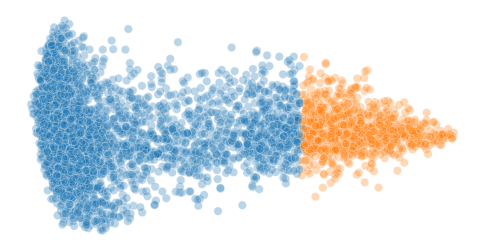

In [50]:
annot_df = pcoa_df.merge(sample_metadata, left_on='SampleId', right_on='srs', how='left')

ANALYSIS_TO_DRAW = "pcoa_split"
# ANALYSIS_TO_DRAW = "random_split_seed_101"
annot_df = attach_test_train_label(annot_df, ANALYSIS_TO_DRAW)

fig, ax = plt.subplots(1, 1, figsize=(6, 3))

#### color by ISO region
# geo_counts = sample_metadata.groupby("iso")['srs'].count().sort_values(ascending=False)
# geo_counts = geo_counts
# color_by = 'iso'
# colors = {iso: np.array([1.0, 1.0, 1.0, 0.2]) for iso in pd.unique(sample_metadata['iso'])}
# colors['US'] = 'tab:blue'
# colors['CA'] = 'tab:orange'
# colors['DK'] = 'red'

#### color by test/train
color_by = 'Label'
colors = {'Train': 'tab:blue', 'Test': 'tab:orange', 'Excluded': 'tab:green'}


sb.scatterplot(
    annot_df,
    x='PC1', y='PC2', hue=color_by, palette=colors,
    alpha=0.3, linewidth=0.5, ec='white', ax=ax,
)

display(prop_var)
explained_pc1 = prop_var['PC1']
explained_pc2 = prop_var['PC2']
ax.set_xlabel(f'PC1 ({explained_pc1 * 100:.2f}%)', fontsize=14, fontname="Fira Sans")
ax.set_ylabel(f'PC2 ({explained_pc2 * 100:.2f}%)', fontsize=14, fontname="Fira Sans")
# ax.set_title('PCoA of samples')
# ax.grid(True, alpha=0.3)
ax.tick_params(
    axis='both',  # Applies to both x and y axis
    which='both', # Applies to both major and minor ticks
    length=0,     # Set tick length to 0 (hides the ticks)
    labelbottom=False, # Hides bottom tick labels
    labelleft=False,   # Hides left tick labels
    labeltop=False,    # Hides top tick labels
    labelright=False   # Hides right tick labels
)

plt.axis('off')
plt.legend().remove()
plt.savefig("pcoa_pcoa_split_NO_AXES.png", bbox_inches='tight', dpi=500, transparent=True)


PC1    0.260537
PC2    0.088646
dtype: float64

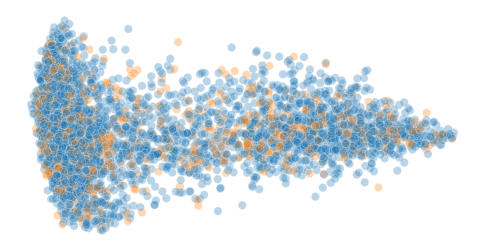

In [49]:
annot_df = pcoa_df.merge(sample_metadata, left_on='SampleId', right_on='srs', how='left')

ANALYSIS_TO_DRAW = "random_split_seed_101"
annot_df = attach_test_train_label(annot_df, ANALYSIS_TO_DRAW)

fig, ax = plt.subplots(1, 1, figsize=(6, 3))

#### color by ISO region
# geo_counts = sample_metadata.groupby("iso")['srs'].count().sort_values(ascending=False)
# geo_counts = geo_counts
# color_by = 'iso'
# colors = {iso: np.array([1.0, 1.0, 1.0, 0.2]) for iso in pd.unique(sample_metadata['iso'])}
# colors['US'] = 'tab:blue'
# colors['CA'] = 'tab:orange'
# colors['DK'] = 'red'

#### color by test/train
color_by = 'Label'
colors = {'Train': 'tab:blue', 'Test': 'tab:orange', 'Excluded': 'tab:green'}


sb.scatterplot(
    annot_df,
    x='PC1', y='PC2', hue=color_by, palette=colors,
    alpha=0.3, linewidth=0.5, ec='white', ax=ax,
)

display(prop_var)
explained_pc1 = prop_var['PC1']
explained_pc2 = prop_var['PC2']
ax.set_xlabel(f'PC1 ({explained_pc1 * 100:.2f}%)', fontsize=14, fontname="Fira Sans")
ax.set_ylabel(f'PC2 ({explained_pc2 * 100:.2f}%)', fontsize=14, fontname="Fira Sans")
# ax.set_title('PCoA of samples')
# ax.grid(True, alpha=0.3)
ax.tick_params(
    axis='both',  # Applies to both x and y axis
    which='both', # Applies to both major and minor ticks
    length=0,     # Set tick length to 0 (hides the ticks)
    labelbottom=False, # Hides bottom tick labels
    labelleft=False,   # Hides left tick labels
    labeltop=False,    # Hides top tick labels
    labelright=False   # Hides right tick labels
)

plt.axis('off')
plt.legend().remove()
plt.savefig("pcoa_random_split_NO_AXES.png", bbox_inches='tight', dpi=500, transparent=True)


In [30]:
# import skbio
# import seaborn as sb
# pcoa_result = skbio.stats.ordination.pcoa(sample_dist_mat, method='eigh')

# """ PCoA based coordinate plotting of samples """
# train_sample_set = set(train_df['srs'])
# test_sample_set = set(test_df['srs'])

# test_train_labels = []
# for sample_id in sample_dist_mat_order:
#     if sample_id in train_sample_set:
#         test_train_labels.append("Train")
#     elif sample_id in test_sample_set:
#         test_train_labels.append("Test")
#     else:
#         test_train_labels.append("Excluded")
        
# coordinates = pcoa_result.samples[['PC1', 'PC2']].assign(SampleId=sample_dist_mat_order).assign(Label=test_train_labels)
# display(coordinates)

# fig, ax = plt.subplots(1, 1, figsize=(8, 6))
# sb.scatterplot(
#     coordinates,
#     x='PC1', y='PC2', hue="Label",
#     alpha=0.3, linewidth=0.
# )  # Plot the first two principal coordinates

# # # Add labels for each point
# # for idx, label in enumerate(coordinates.index):
# #     plt.annotate(label, (coordinates.iloc[idx, 0], coordinates.iloc[idx, 1]))

# # Get proportion of variance explained
# prop_var = pcoa_result.proportion_explained
# print(prop_var)

# plt.xlabel(f'PC1 ({prop_var[0]*100:.2f}%)')
# plt.ylabel(f'PC2 ({prop_var[1]*100:.2f}%)')
# plt.title('PCoA Plot')
# plt.grid(True, alpha=0.3)
# plt.show()

In [31]:
# from sklearn.manifold import MDS

# embedding = MDS(n_components=2, dissimilarity='precomputed', metric=True, n_jobs=10)
# mds_fit_result = embedding.fit_transform(sample_dist_mat)

In [ ]:
# # Specify both columns and index
# train_sample_set = set(train_df['srs'])
# test_sample_set = set(test_df['srs'])

# test_train_labels = []
# for sample_id in sample_dist_mat_order:
#     if sample_id in train_sample_set:
#         test_train_labels.append("Train")
#     elif sample_id in test_sample_set:
#         test_train_labels.append("Test")
#     else:
#         test_train_labels.append("Excluded")
        
# coordinates = pd.DataFrame(mds_fit_result, columns=['X', 'Y']).assign(SampleId=sample_dist_mat_order).assign(Label=test_train_labels)
# display(coordinates)

# fig, ax = plt.subplots(1, 1, figsize=(8, 6))
# sb.scatterplot(
#     coordinates,
#     x='X', y='Y', hue="Label",
#     alpha=0.3, linewidth=0.
# )
# print(embedding.stress_)

# plt.title('Metric-MDS Plot')
# plt.grid(True, alpha=0.3)
# plt.show()

## sanity checks

In [20]:
# sanity check: make sure samples don't overlap.
# Reload from the saved file, just as an extra layer of sanity check.
for analysis_name in analysis_names: 
    analysis_dir = ANALYSIS_DIR / analysis_name
    print(f"Analysis subdir: {analysis_dir}")
    train_df = pd.read_csv(analysis_dir / "train.tsv", sep="\t")
    test_df = pd.read_csv(analysis_dir / "test.tsv", sep="\t")
    
    print("Total samples: {}".format(sample_subset.shape[0]))
    print("# train samples: {}".format(train_df.shape[0]))
    print("# test samples: {}".format(test_df.shape[0]))
    print("Ratio: {} / {} = {}".format(
        train_df.shape[0], test_df.shape[0], train_df.shape[0] / test_df.shape[0]
    ))
    
    assert len(set(train_df['srs']).intersection(set(test_df['srs']))) == 0, "Train and test share samples! (this should never happen)"

Analysis subdir: /data/bwh-comppath-seq/youn/human_microbiome_compendium/american_gut/analyses/pcoa_split
Total samples: 3851
# train samples: 3080
# test samples: 771
Ratio: 3080 / 771 = 3.9948119325551232
Analysis subdir: /data/bwh-comppath-seq/youn/human_microbiome_compendium/american_gut/analyses/random_split_seed_100
Total samples: 3851
# train samples: 3080
# test samples: 770
Ratio: 3080 / 770 = 4.0
Analysis subdir: /data/bwh-comppath-seq/youn/human_microbiome_compendium/american_gut/analyses/random_split_seed_101
Total samples: 3851
# train samples: 3080
# test samples: 770
Ratio: 3080 / 770 = 4.0
Analysis subdir: /data/bwh-comppath-seq/youn/human_microbiome_compendium/american_gut/analyses/random_split_seed_102
Total samples: 3851
# train samples: 3080
# test samples: 770
Ratio: 3080 / 770 = 4.0
Analysis subdir: /data/bwh-comppath-seq/youn/human_microbiome_compendium/american_gut/analyses/random_split_seed_103
Total samples: 3851
# train samples: 3080
# test samples: 770
Ratio

# Create TRAIN and TEST ASV subset ID files.

This is for the pre-computation of the test vs. train ASV nearest-neighbor calculations (downstream analysis, enabling nearest-neighbor baseline methods)

## Step 1 -- create the train/test ASV id files.

In [22]:
from common.preprocess import dump_asv_ids

def generate_nn_lookup_command(out_dir: Path, train_df: pd.DataFrame, test_df: pd.DataFrame, abundance_table_dir: Path, asv_seqs_subset: Dict[str, str], name: str) -> str:
    train_in = out_dir / f"asv_ids.train.{name}.txt"
    test_in = out_dir / f"asv_ids.test.{name}.txt"
    out_path = out_dir / f"precomputed.{name}.tsv"
    
    # dump_asv_ids(asv_seqs_subset, train_df, abundance_table_dir, train_in)
    # dump_asv_ids(asv_seqs_subset, test_df, abundance_table_dir, test_in)
    command = f'aligned_nearest_neighbor -i "{asv_align_file}" -o "{out_path.name}" -n {n_suggested_workers} -q "{test_in.name}" -d "{train_in.name}"'
    return command


n_suggested_workers = 20
suggested_commands = []

for analysis_name in analysis_names:
    analysis_dir = ANALYSIS_DIR / analysis_name
    train_df = pd.read_csv(analysis_dir / "train.tsv", sep="\t")
    test_df = pd.read_csv(analysis_dir / "test.tsv", sep="\t")
    
    nn_lookup_dir = analysis_dir / 'nearest_neighbors'
    nn_lookup_dir.mkdir(exist_ok=True)
    print(f"********* {analysis_name} [{train_df.shape[0]} test vs {test_df.shape[0]} train] **********")
    print(f"Analysis subdir: {analysis_dir}")
    print("Initializing train/test nearest-neighbor precalculation in: {}".format(nn_lookup_dir))
    suggested_commands.append(f"cd {nn_lookup_dir}")

    # dump entire set
    suggested_commands.append(
        generate_nn_lookup_command(nn_lookup_dir, train_df, test_df, abundance_table_dir, asv_seqs_subset, name="all")
    )

    # dump by project
    for proj_id, test_proj_section in test_df.groupby("project"):
        train_proj_section = train_df.loc[train_df['project'] == proj_id]
        if train_proj_section.shape[0] == 0:
            print(f"Project {proj_id} was in test set, but not in train set. Skipping paired nearest-neighbor query builder!")
        else:
            suggested_commands.append(
                generate_nn_lookup_command(nn_lookup_dir, train_proj_section, test_proj_section, abundance_table_dir, asv_seqs_subset, name=proj_id)
            )

print("Run these commands to pre-calculate all nearest neighbor queries:")
print("\n\n")
for cmd in suggested_commands:
    print(f"{cmd}")

********* pcoa_split [3080 test vs 771 train] **********
Analysis subdir: /data/bwh-comppath-seq/youn/human_microbiome_compendium/american_gut/analyses/pcoa_split
Initializing train/test nearest-neighbor precalculation in: /data/bwh-comppath-seq/youn/human_microbiome_compendium/american_gut/analyses/pcoa_split/nearest_neighbors
********* random_split_seed_100 [3080 test vs 770 train] **********
Analysis subdir: /data/bwh-comppath-seq/youn/human_microbiome_compendium/american_gut/analyses/random_split_seed_100
Initializing train/test nearest-neighbor precalculation in: /data/bwh-comppath-seq/youn/human_microbiome_compendium/american_gut/analyses/random_split_seed_100/nearest_neighbors
********* random_split_seed_101 [3080 test vs 770 train] **********
Analysis subdir: /data/bwh-comppath-seq/youn/human_microbiome_compendium/american_gut/analyses/random_split_seed_101
Initializing train/test nearest-neighbor precalculation in: /data/bwh-comppath-seq/youn/human_microbiome_compendium/americ

# Old code below (unused)

In [119]:
project_subset

,project,link,amplicon,avg_length,bead_beating,kit,sample_type,condition,subjects,notes
4,PRJDB10527,https://doi.org/10.1186/s12866-021-02215-0,v3-v4,274.78,True,Gene Prep Star PI-480 device (Kurabo Industries),stool,healthy,adults,NaN
5,PRJDB10612,https://doi.org/10.1016/j.foodres.2021.110326,v3-v4,254.00,True,Gene Prep Star PI-480,stool,healthy,adults,"Beads used, but for purification"
38,PRJNA625181,https://doi.org/10.1038/s43587-021-00129-0,v3-v4,420.40,True,TIANamp Stool DNA Kit,stool,healthy,adults,NaN
41,PRJEB11419,https://doi.org/10.1128/mSystems.00031-18,v4,126.93,False,NaN,stool,healthy,adults,NaN
50,PRJEB42056,https://doi.org/10.1128/mSystems.01329-20,v4,126.95,True,custom,"stool, saliva, skin",healthy,adults,NaN
56,PRJEB40569,https://doi.org/10.3389/fcimb.2022.722886,v3-v4,380.96,True,NucleoSpin DNA Stool kit,stool,healthy,adults,NaN
60,PRJEB35769,https://doi.org/10.1038/s41598-020-72161-w,v3-v4,385.52,True,custom,stool,healthy,adults,"mechanical lysis (FastprepFP120; ThermoSavant,..."
64,PRJEB33065,https://doi.org/10.1128/mSystems.00864-19,v4,126.89,True,PowerSoil kit,stool,healthy,adults,NaN
68,PRJEB36316,https://doi.org/10.1080/19490976.2020.1840764,v4,127.00,True,Quick-DNA Fecal/Soil Microbe Miniprep Kit,stool,healthy,adults,NaN
70,PRJEB33905,https://doi.org/10.1128/mSystems.00179-21,v3-v4,401.41,False,"QIAamp DNA stool minikit (Qiagen, Hilden, Germ...",stool,healthy,adults,NaN


In [26]:
# # from common.util import ASVDistanceMatrixSparse

# # distmat_file = asv_align_file.parent / "distance_matrix.npz"
# # if distmat_file.exists():
# #     dist_mat = ASVDistanceMatrixSparse.load(distmat_file)
# # else:
# #     dist_mat = ASVDistanceMatrixSparse.from_alignment_sparse(asv_align_file, n_threads=20)
# #     dist_mat.save(asv_align_file.parent / "distance_matrix.npz")
# distmat_variable_name = 'dist_mat'
# if distmat_variable_name in locals() or distmat_variable_name in globals():
#     print(f"'{distmat_variable_name}' exists.")
#     dist_mat.shutdown()
#     del dist_mat

In [40]:
# from common.util import ASVDistanceMatrixLazy
# dist_mat = ASVDistanceMatrixLazy(asv_align_file, n_workers=20)


# train_df, test_df = train_test_split_mincut_approximation(
#     sample_df=sample_subset, 
#     abundance_table_dir=abundance_table_dir,
#     asv_id_subset=set(asv_seqs_subset.keys()), 
#     train_fraction=0.8, 
#     test_fraction=0.2,
#     distance_matrix=dist_mat,
# )
# train_df.to_csv(NOTEBOOK_CACHE / "train.tsv", sep="\t", index=False)
# test_df.to_csv(NOTEBOOK_CACHE / "test.tsv", sep="\t", index=False)
    
# print("# train samples: {}".format(train_df.shape[0]))
# print("# test samples: {}".format(test_df.shape[0]))
# print("Ratio: {} / {} = {}".format(
#     train_df.shape[0], test_df.shape[0], train_df.shape[0] / test_df.shape[0]
# ))

# dist_mat.shutdown()

In [49]:
sample_subset.groupby('region')['srs'].count()

region
Australia/New Zealand                 78
Central and Southern Asia              5
Eastern and South-Eastern Asia       345
Europe and Northern America         8454
Latin America and the Caribbean        1
Northern Africa and Western Asia       4
Oceania                                4
Sub-Saharan Africa                   542
unknown                             2641
Name: srs, dtype: int64

In [37]:
train_df.groupby("project")['srs'].count().to_frame()

,srs
project,
PRJDB10527,39
PRJDB10612,67
PRJEB11419,3078
PRJEB23775,86
PRJEB31155,1
PRJEB32537,16
PRJEB33065,19
PRJEB33905,489
PRJEB35769,169


In [38]:
test_df.groupby("project")['srs'].count().to_frame()

,srs
project,
PRJDB10527,10
PRJDB10612,17
PRJEB11419,770
PRJEB23775,22
PRJEB31155,1
PRJEB32537,4
PRJEB33065,5
PRJEB33905,123
PRJEB35769,43


In [39]:
project_subset

,project,link,amplicon,avg_length,bead_beating,kit,sample_type,condition,subjects,notes
4,PRJDB10527,https://doi.org/10.1186/s12866-021-02215-0,v3-v4,274.78,True,Gene Prep Star PI-480 device (Kurabo Industries),stool,healthy,adults,NaN
5,PRJDB10612,https://doi.org/10.1016/j.foodres.2021.110326,v3-v4,254.00,True,Gene Prep Star PI-480,stool,healthy,adults,"Beads used, but for purification"
38,PRJNA625181,https://doi.org/10.1038/s43587-021-00129-0,v3-v4,420.40,True,TIANamp Stool DNA Kit,stool,healthy,adults,NaN
41,PRJEB11419,https://doi.org/10.1128/mSystems.00031-18,v4,126.93,False,NaN,stool,healthy,adults,NaN
50,PRJEB42056,https://doi.org/10.1128/mSystems.01329-20,v4,126.95,True,custom,"stool, saliva, skin",healthy,adults,NaN
56,PRJEB40569,https://doi.org/10.3389/fcimb.2022.722886,v3-v4,380.96,True,NucleoSpin DNA Stool kit,stool,healthy,adults,NaN
60,PRJEB35769,https://doi.org/10.1038/s41598-020-72161-w,v3-v4,385.52,True,custom,stool,healthy,adults,"mechanical lysis (FastprepFP120; ThermoSavant,..."
64,PRJEB33065,https://doi.org/10.1128/mSystems.00864-19,v4,126.89,True,PowerSoil kit,stool,healthy,adults,NaN
68,PRJEB36316,https://doi.org/10.1080/19490976.2020.1840764,v4,127.00,True,Quick-DNA Fecal/Soil Microbe Miniprep Kit,stool,healthy,adults,NaN
70,PRJEB33905,https://doi.org/10.1128/mSystems.00179-21,v3-v4,401.41,False,"QIAamp DNA stool minikit (Qiagen, Hilden, Germ...",stool,healthy,adults,NaN
